In [2]:
#import some necessary libraries
import datetime
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
%matplotlib inline
import matplotlib.pyplot as plt  # Matlab-style plotting
import seaborn as sns
color = sns.color_palette()
sns.set_style('darkgrid')
#import warnings
#def ignore_warn(*args, **kwargs):
#    pass
#warnings.warn = ignore_warn #ignore annoying warning (from sklearn and seaborn)
import time

from scipy import stats
from scipy.stats import norm, skew, kurtosis, boxcox #for some statistics
from scipy.special import boxcox1p, inv_boxcox, inv_boxcox1p
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, LabelEncoder, RobustScaler, StandardScaler
from sklearn.decomposition import PCA, NMF
from sklearn.feature_selection import SelectKBest, chi2

pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x)) #Limiting floats output to 3 decimal points

from subprocess import check_output

StartTime = datetime.datetime.now()

In [3]:
class MyTimer():
    # usage:
    #with MyTimer():
    #    rf.fit(X_train, y_train)
    def __init__(self):
        self.start = time.time()
    def __enter__(self):
        return self
    def __exit__(self, exc_type, exc_val, exc_tb):
        end = time.time()
        runtime = end - self.start
        msg = 'The function took {time} seconds to complete'
        print(msg.format(time=runtime))

In [7]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')


In [9]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.000,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.000,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


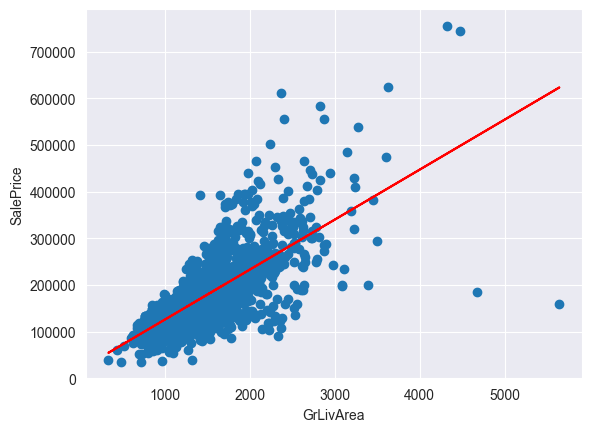

In [27]:
# fig, ax = plt.subplots()
# 散布図
plt.scatter(x=train["GrLivArea"], y=train["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

# 多項式
m, b = np.polyfit(train["GrLivArea"], train["SalePrice"], 1)
plt.plot(train["GrLivArea"], train["GrLivArea"] * m + b, color='red')

plt.show()

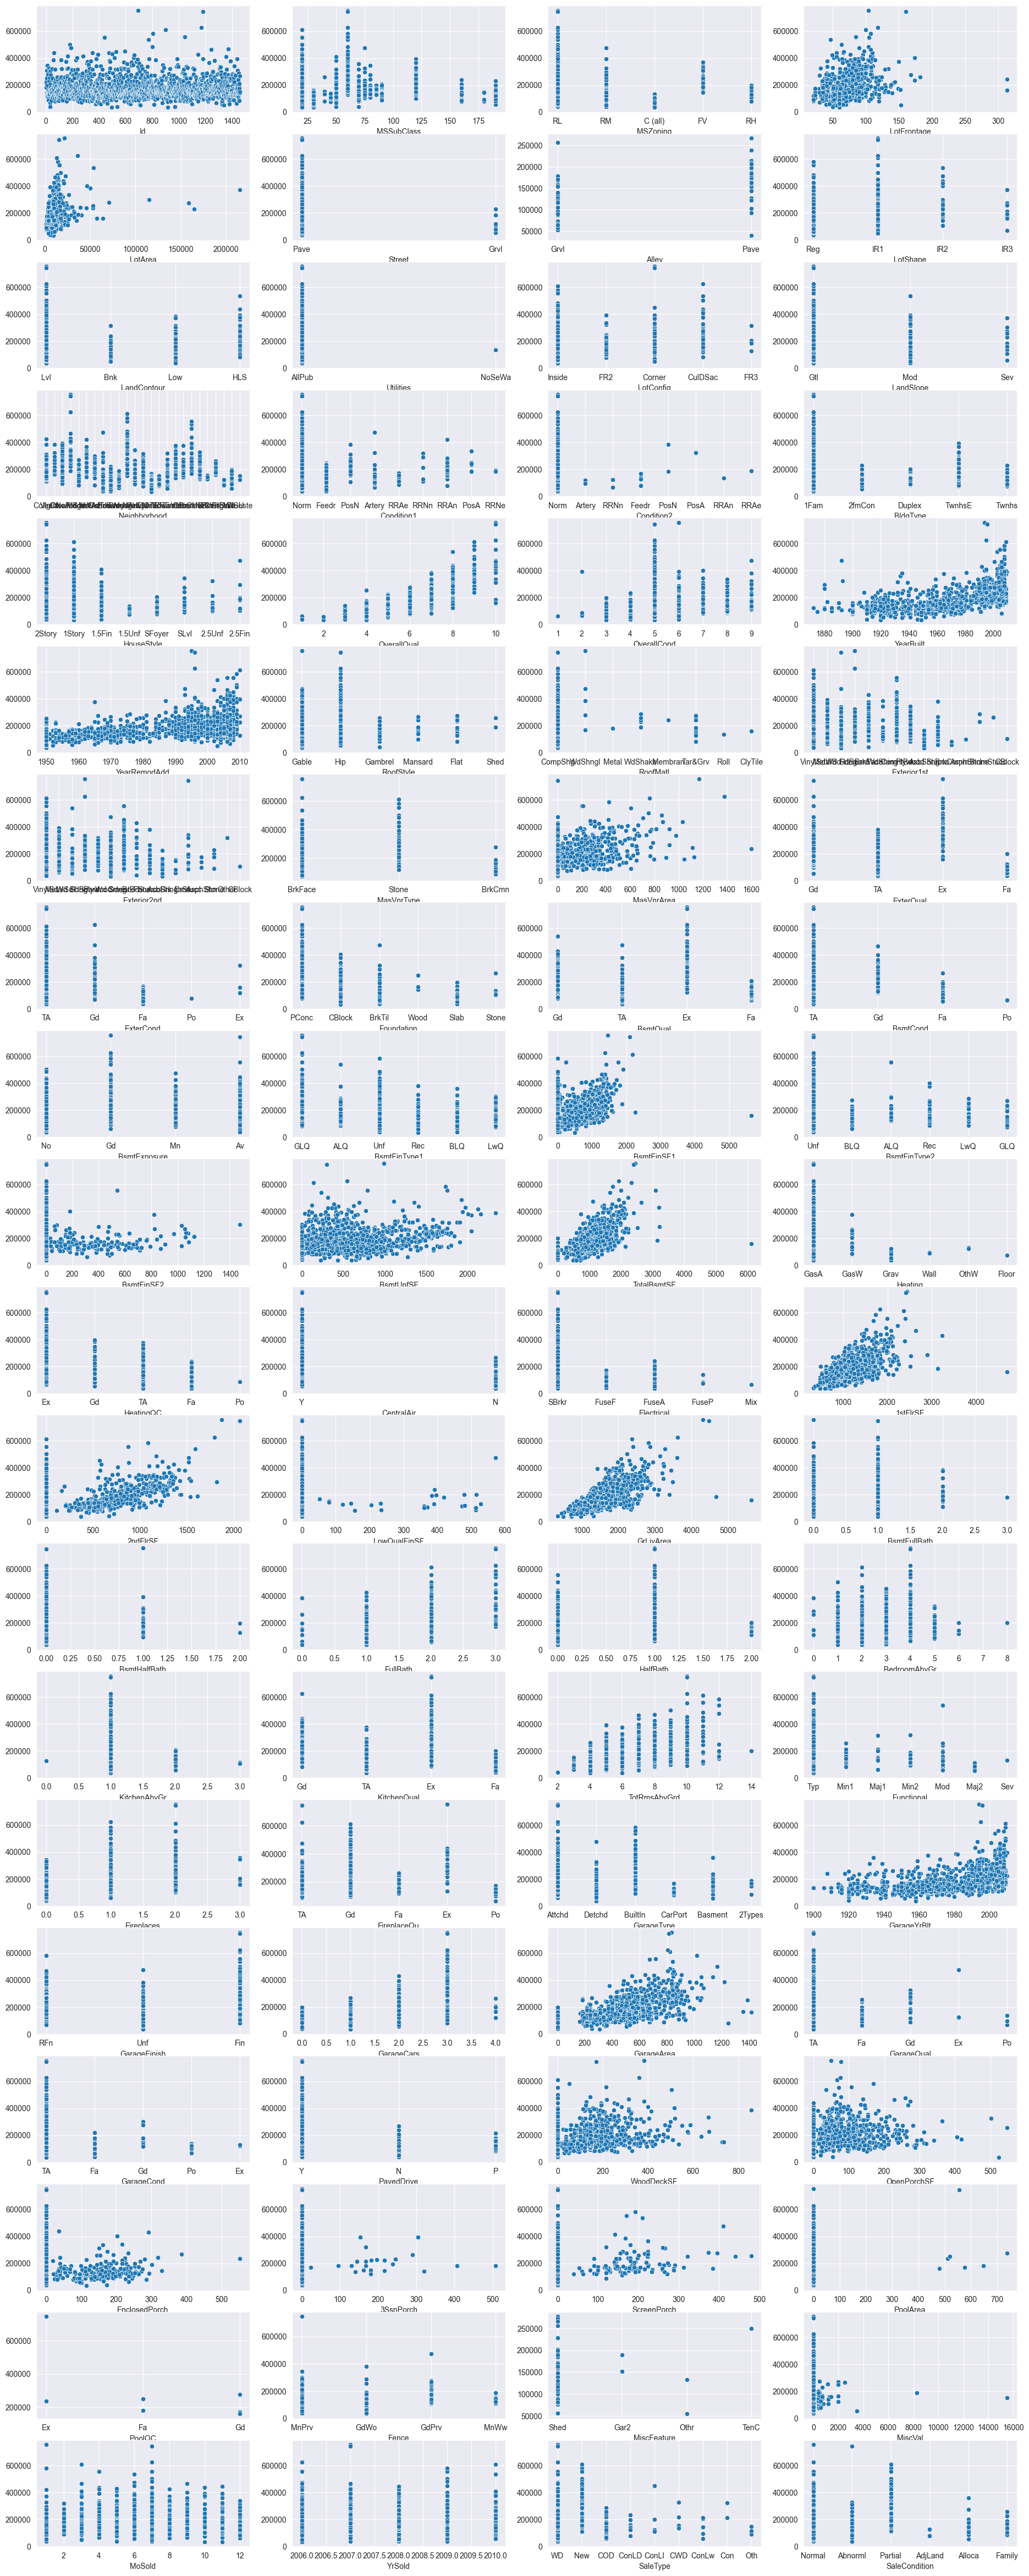

In [51]:
from math import ceil

grid_cols = 4
grid_rows = ceil((train.shape[1] - 1) / grid_cols)
col_names = train.columns.drop('SalePrice')

fig, ax = plt.subplots(grid_rows, grid_cols, figsize=(23,60))
for col_name, subplot in zip(col_names, ax.flatten()):
    sns.scatterplot(x=col_name, y="SalePrice", data=train, ax=subplot)
    subplot.set_xlabel(col_name, fontsize=10)  # x軸ラベルを追加
    subplot.set_ylabel('')  # y軸ラベルを空にする

In [53]:
#check the numbers of samples and features
print("The train data size before dropping Id feature is : {} ".format(train.shape))
print("The test data size before dropping Id feature is : {} ".format(test.shape))

#Save the 'Id' column
train_ID = train['Id']
test_ID = test['Id']


#Now drop the  'Id' colum since it's unnecessary for  the prediction process.
train.drop("Id", axis = 1, inplace = True)
test.drop("Id", axis = 1, inplace = True)

#check again the data size after dropping the 'Id' variable
print("\nThe train data size after dropping Id feature is : {} ".format(train.shape)) 
print("The test data size after dropping Id feature is : {} ".format(test.shape))

The train data size before dropping Id feature is : (1460, 81) 
The test data size before dropping Id feature is : (1459, 80) 

The train data size after dropping Id feature is : (1460, 80) 
The test data size after dropping Id feature is : (1459, 79) 


[5.32820006e-04 1.12165815e+01]


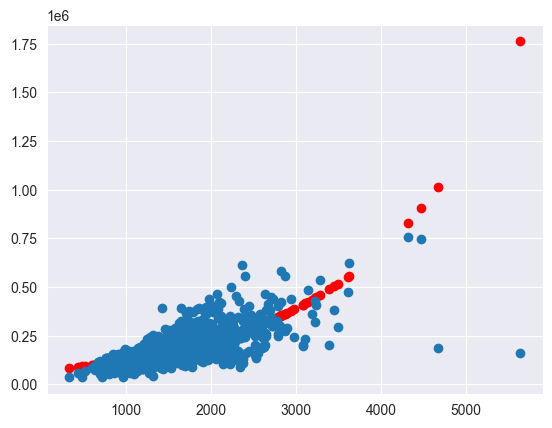

In [54]:
# linears
x_data = train['GrLivArea']
y_data = train['SalePrice']
log_y_data = np.log(train['SalePrice'])

curve_fit = np.polyfit(x_data, log_y_data, 1)
print(curve_fit)
y = np.exp(1.11618915e+01) * np.exp(5.70762509e-04*x_data)
plt.plot(x_data, y_data, "o")
plt.scatter(x_data, y,c='red')

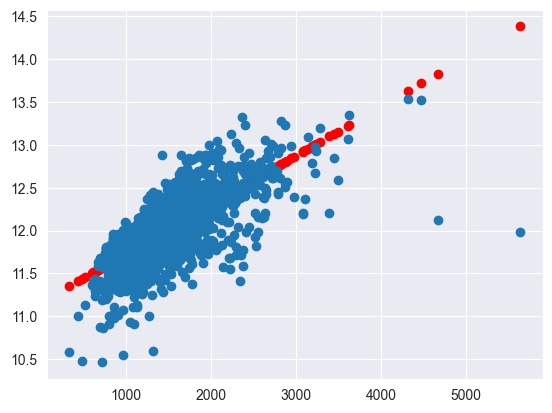

In [55]:
# linear with log y
y = np.exp(1.11618915e+01) * np.exp(5.70762509e-04*x_data)
plt.plot(x_data, np.log(y_data), "o")
plt.scatter(x_data, np.log(y),c='red')


 mu = 180921.20 and sigma = 79415.29, skew = 1.88 kurtosis = 6.51



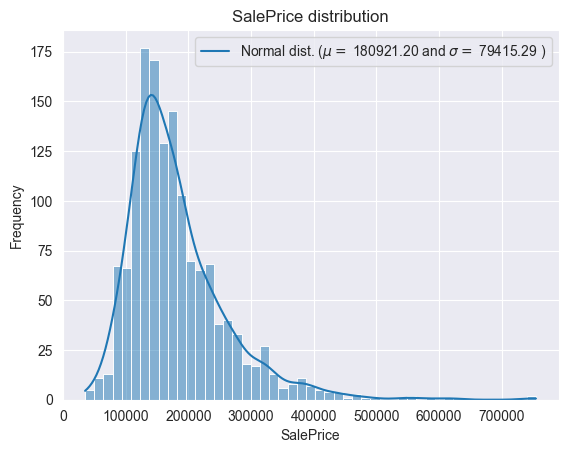

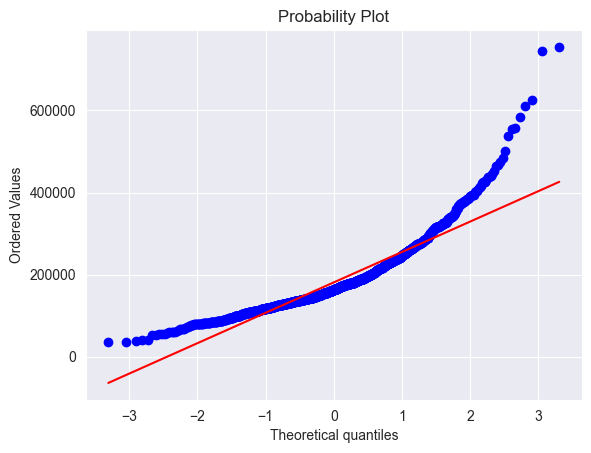

In [ ]:
sns.histplot(train['SalePrice'], kde=True)

_skew = skew(train['SalePrice'])
_kurtosis = kurtosis(train['SalePrice'])

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}, skew = {:.2f} kurtosis = {:.2f}\n'.format(mu, sigma, _skew, _kurtosis))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

In [60]:
#We try the numpy function log1p which  applies log(1+x) to all elements of the column

# option 1 - original
#train["SalePrice"] = np.log1p(train["SalePrice"])

# Option 2: use box-cox transform - this performs better than the log(1+x)
# try different alpha values  between 0 and 1
lam_l = 0.35 # optimized value
train["SalePrice"] = boxcox1p(train["SalePrice"], lam_l)

# Option 3: boxcox letting the algorithm select lmbda based on least-likelihood calculation
#train["SalePrice"], lam_l = boxcox1p(x=train["SalePrice"], lmbda=None)

# option 4 - use log, compare to log1p => score is same
#train["SalePrice"] = np.log(train["SalePrice"])


/var/folders/4s/r4171zwx5j57sgcgtx7j0qvc0000gn/T/ipykernel_78252/3389563975.py:2: RuntimeWarning: divide by zero encountered in log
  y1 = np.log(x)


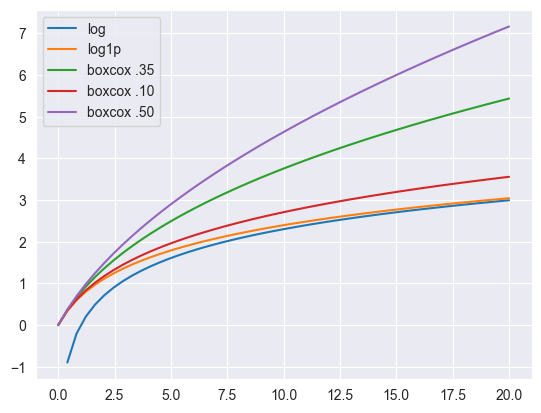

/var/folders/4s/r4171zwx5j57sgcgtx7j0qvc0000gn/T/ipykernel_78252/3389563975.py:16: RuntimeWarning: divide by zero encountered in log
  y1 = np.log(x)


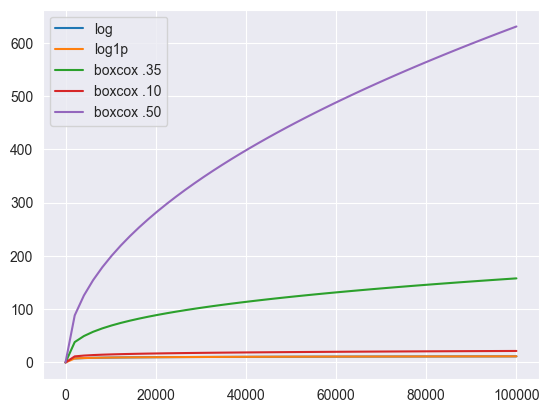

In [61]:
x = np.linspace(0, 20)
y1 = np.log(x)
y2 = np.log1p(x)
y3 = boxcox1p(x, 0.35)
y4 = boxcox1p(x, 0.10)
y5 = boxcox1p(x, 0.50)
plt.plot(x,y1,label='log') 
plt.plot(x,y2,label='log1p') 
plt.plot(x,y3,label='boxcox .35') 
plt.plot(x,y4,label='boxcox .10') 
plt.plot(x,y5,label='boxcox .50') 
plt.legend()
plt.show()

x = np.linspace(0, 100000)
y1 = np.log(x)
y2 = np.log1p(x)
y3 = boxcox1p(x, 0.35)
y4 = boxcox1p(x, 0.10)
y5 = boxcox1p(x, 0.50)
plt.plot(x,y1,label='log') 
plt.plot(x,y2,label='log1p') 
plt.plot(x,y3,label='boxcox .35') 
plt.plot(x,y4,label='boxcox .10') 
plt.plot(x,y5,label='boxcox .50') 
plt.legend()
plt.show()


 mu = 191.19 and sigma = 27.60, skew = 0.69 kurtosis = 1.31



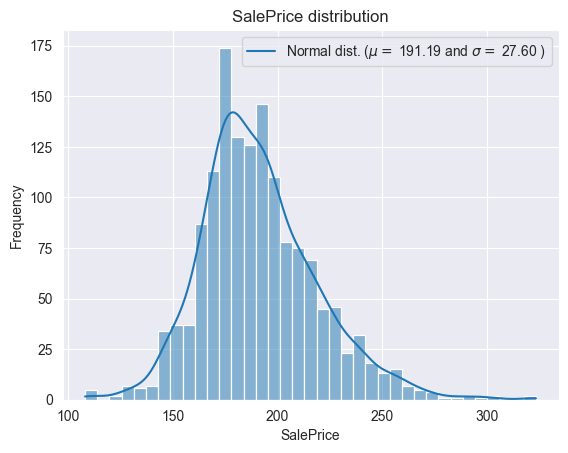

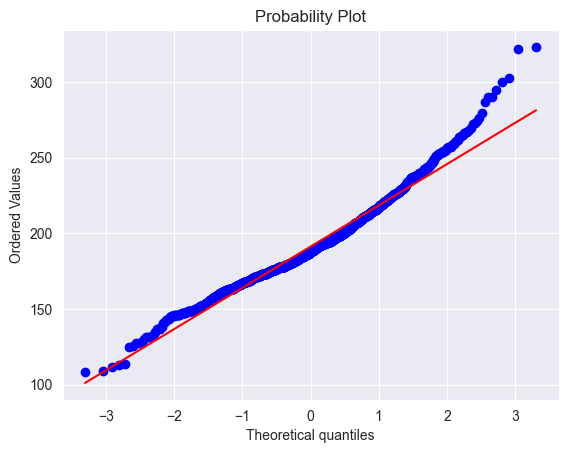

In [64]:
# to revert back use y = inv_boxcox1p(x, lam_l) => train["SalePrice"] = inv_boxcox1p(train["SalePrice"], lam_l)
# think the underlying formula is this: # pred_y = np.power((y_box * lambda_) + 1, 1 / lambda_) - 1

#Check the new distribution
sns.histplot(train['SalePrice'], kde=True)

_skew = skew(train['SalePrice'])
_kurtosis = kurtosis(train['SalePrice'])

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}, skew = {:.2f} kurtosis = {:.2f}\n'.format(mu, sigma, _skew, _kurtosis))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

In [65]:
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train.SalePrice.values
all_data = pd.concat((train, test)).reset_index(drop=True)
all_data.drop(['SalePrice'], axis=1, inplace=True)
print("all_data size is : {}".format(all_data.shape))

all_data size is : (2919, 79)


In [66]:
def add_gla(row, p):
    return (p[2] + p[1]*row.GrLivArea + p[0]*(row.GrLivArea**2))

#all_data['GrLivAreaPoly'] = all_data.apply(lambda row: add_gla(row,curve_fit_gla), axis=1)

In [67]:
all_data.GrLivArea[:ntrain]

0       1710
1       1262
2       1786
3       1717
4       2198
        ... 
1455    1647
1456    2073
1457    2340
1458    1078
1459    1256
Name: GrLivArea, Length: 1460, dtype: int64

In [68]:
correlation_matrix = np.corrcoef(all_data.GrLivArea[:ntrain], y_train)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2

print(r_squared)

0.5077491709588581


In [69]:
from sklearn.feature_selection import mutual_info_regression

# GrLivArea と SalePrice の相互情報量を計算
mi = mutual_info_regression(all_data.GrLivArea[:ntrain].values.reshape(-1, 1), y_train)
print(f"Mutual Information: {mi[0]:.4f}")

Mutual Information: 0.4650


In [70]:
for i in range(1,11,1):
    j = i/10
    correlation_matrix = np.corrcoef(all_data.GrLivArea[:ntrain]**j, y_train)
    correlation_xy = correlation_matrix[0,1]
    r_squared = correlation_xy**2

    print(j, r_squared)

0.1 0.5305183662637588
0.2 0.5312670563956291
0.3 0.531255244503499
0.4 0.5304592583725706
0.5 0.5288536178938208
0.6 0.5264116555148897
0.7 0.5231062363309824
0.8 0.518910588815453
0.9 0.5137992557130445
1.0 0.5077491709588581
